In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Use this if ../data/ is not working
data = pd.read_csv(r'C:\Users\Monishaa Sri .P\My GitHub Projects\medical-insurance-analysis\data\insurance project.csv')

print("Loaded successfully!")
print("Shape:", data.shape)

Loaded successfully!
Shape: (1338, 7)


In [14]:
print(data.head(5))

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [5]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


In [3]:
print(data.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [4]:
print(data.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:
print(data.duplicated().sum())

1


In [6]:
data = data.drop_duplicates()
print(data.duplicated().sum())

0


In [7]:
print(data["charges"].mean())

13279.121486655948


In [8]:
print(data["charges"].max())

63770.42801


In [9]:
print(data["charges"].min())

1121.8739


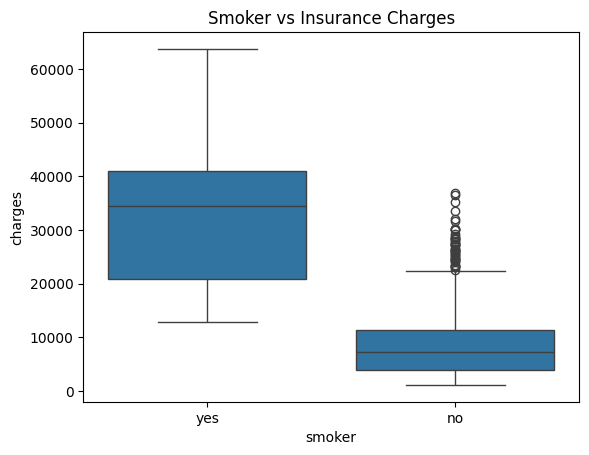

In [10]:
sns.boxplot(x="smoker", y="charges", data=data)

plt.title("Smoker vs Insurance Charges")

plt.show()

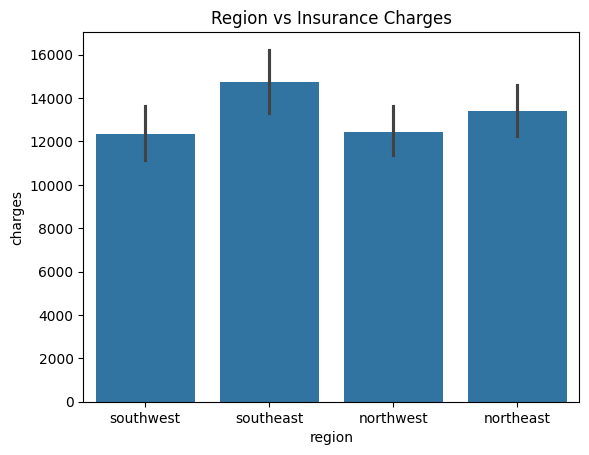

In [11]:
sns.barplot(x="region", y="charges", data=data)

plt.title("Region vs Insurance Charges")

plt.show()

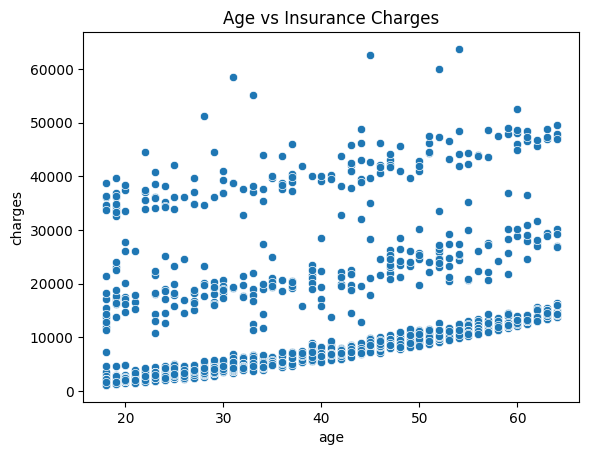

In [12]:
sns.scatterplot(x="age", y="charges", data=data)

plt.title("Age vs Insurance Charges")

plt.show()

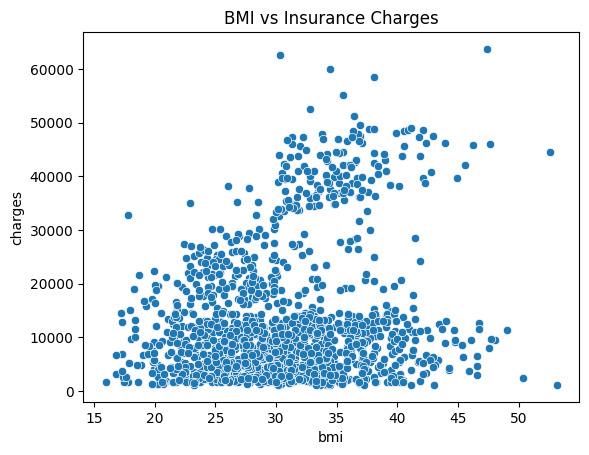

In [13]:
sns.scatterplot(x="bmi", y="charges", data=data)

plt.title("BMI vs Insurance Charges")

plt.show()

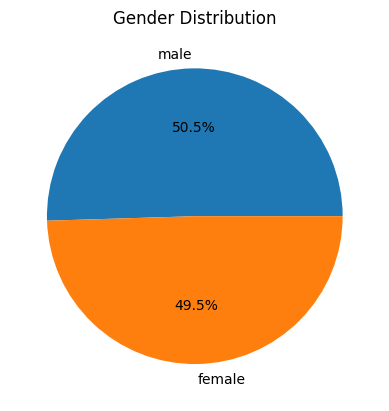

In [14]:
data["sex"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.show()

In [17]:
encoded_data = data.copy()

encoded_data["sex"] = encoded_data["sex"].map({
    "male": 0,
    "female": 1
})

encoded_data["smoker"] = encoded_data["smoker"].map({
    "no": 0,
    "yes": 1
})

encoded_data["region"] = encoded_data["region"].map({
    "southwest": 0,
    "southeast": 1,
    "northwest": 2,
    "northeast": 3
})

In [18]:
correlation = encoded_data.corr()

print(correlation)

               age       sex       bmi  children    smoker    region   charges
age       1.000000  0.019814  0.109344  0.041536 -0.025587 -0.001626  0.298308
sex       0.019814  1.000000 -0.046397 -0.017848 -0.076596  0.004936 -0.058044
bmi       0.109344 -0.046397  1.000000  0.012755  0.003746 -0.157574  0.198401
children  0.041536 -0.017848  0.012755  1.000000  0.007331 -0.016258  0.067389
smoker   -0.025587 -0.076596  0.003746  0.007331  1.000000  0.002358  0.787234
region   -0.001626  0.004936 -0.157574 -0.016258  0.002358  1.000000  0.006547
charges   0.298308 -0.058044  0.198401  0.067389  0.787234  0.006547  1.000000


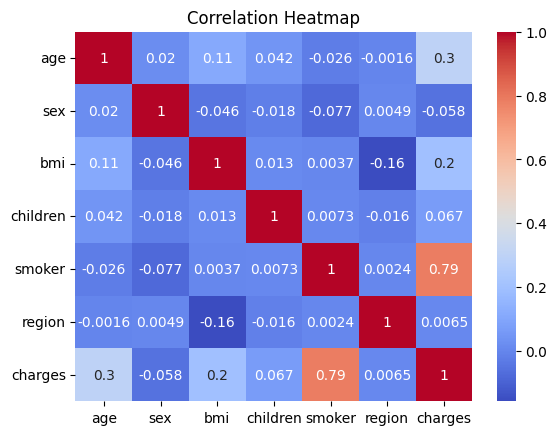

In [19]:
sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [20]:
print("1. Smokers have higher insurance charges.")

print("2. Age and BMI influence insurance cost.")

print("3. Regional differences exist in charges.")

print("4. Charges increase for some high BMI individuals.")

1. Smokers have higher insurance charges.
2. Age and BMI influence insurance cost.
3. Regional differences exist in charges.
4. Charges increase for some high BMI individuals.
